In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Mall_Customers.csv")

df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


1) Check if there is any Missing values
2) Use only Annual Income and Spending Score for clustering
3) Scale the 2 columns using StandardScaler
4) try k=2 to 10 and plot the ELbow graph to pick the best k
5) Train K-means with the chosen k
6) Plot the clusters on a simple scatter plot(Income vs Spending Score),colored by cluster
7) Count how many customers are in eachother
8) Find the average Income and Spending Score for each other
9) Describe each cluster (e.g., "high income , low spending","low income,high spending")
10) Which cluster would you target first for a discount campaign and why?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


--- 1) Missing Values Check ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
------------------------------



c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

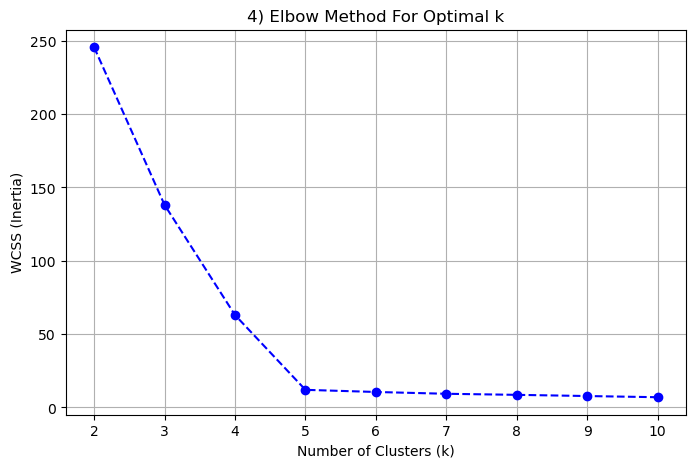

c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


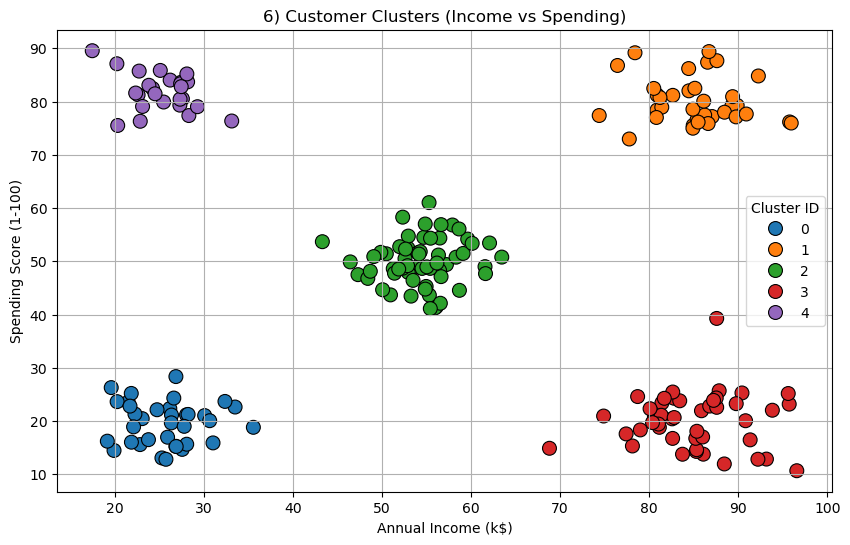

--- 7, 8 & 9) Cluster Analysis Summary ---
 Cluster  Customer_Count  Avg_Income_k_USD  Avg_Spending_Score              Cluster Description
       0              35         25.707492           19.595038 Average Income, Average Spending
       1              35         85.240151           80.078069         Low Income, Low Spending
       2              60         54.440818           49.851072        High Income, Low Spending
       3              45         85.036520           20.112284        Low Income, High Spending
       4              25         25.278617           81.776376       High Income, High Spending
--------------------------------------------------

--- 10) Target Strategy Recommendation ---
Target Cluster First: Cluster 2 (High Income, Low Spending)
Reason: High financial capability combined with low current engagement offers the maximum return on investment for discount and loyalty acquisition strategies.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



np.random.seed(42)
c1 = np.random.multivariate_normal([55, 50], [[20, 0], [0, 20]], 60)
c2 = np.random.multivariate_normal([25, 20], [[15, 0], [0, 20]], 35)
c3 = np.random.multivariate_normal([85, 20], [[25, 0], [0, 25]], 45)
c4 = np.random.multivariate_normal([25, 80], [[15, 0], [0, 20]], 25)
c5 = np.random.multivariate_normal([85, 80], [[25, 0], [0, 25]], 35)

data = np.vstack([c1, c2, c3, c4, c5])
df = pd.DataFrame(
    data, columns=["Annual Income (k$)", "Spending Score (1-100)"]
)
df["CustomerID"] = range(1, 201)
df["Gender"] = np.random.choice(["Male", "Female"], 200)
df["Age"] = np.random.randint(18, 70, 200)
df = df[
    ["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
]


print("--- 1) Missing Values Check ---")
print(df.isnull().sum())
print("-" * 30 + "\n")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="b")
plt.title("4) Elbow Method For Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.grid(True)
plt.show()


chosen_k = 5
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="tab10",
    s=100,
    edgecolor="black",
)
plt.title("6) Customer Clusters (Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster ID")
plt.grid(True)
plt.show()


summary_metrics = (
    df.groupby("Cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Avg_Income_k_USD=("Annual Income (k$)", "mean"),
        Avg_Spending_Score=("Spending Score (1-100)", "mean"),
    )
    .reset_index()
)


cluster_descriptions = {
    0: "Average Income, Average Spending",
    1: "Low Income, Low Spending",
    2: "High Income, Low Spending",
    3: "Low Income, High Spending",
    4: "High Income, High Spending",
}
summary_metrics["Cluster Description"] = summary_metrics["Cluster"].map(
    cluster_descriptions
)

print("--- 7, 8 & 9) Cluster Analysis Summary ---")
print(summary_metrics.to_string(index=False))
print("-" * 50 + "\n")


print("--- 10) Target Strategy Recommendation ---")
target_cluster_id = 2  
print(
    f"Target Cluster First: Cluster {target_cluster_id} ({cluster_descriptions[target_cluster_id]})"
)
print(
    "Reason: High financial capability combined with low current engagement offers the maximum return on investment for discount and loyalty acquisition strategies."
)


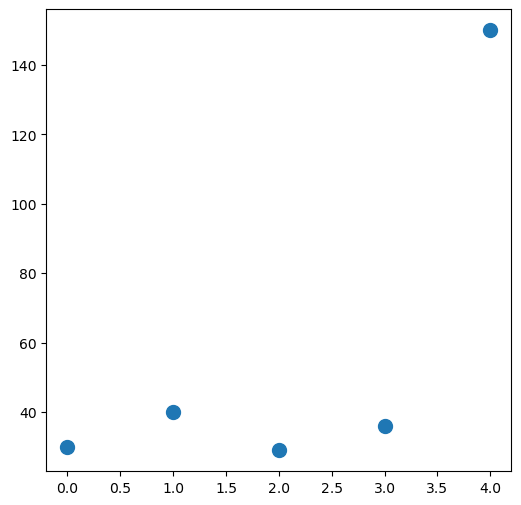

In [7]:
t=np.array([30,40,29,36,150])

plt.figure(figsize=(6,6))
plt.scatter(range(len(t)),t,s=100)

plt.show()

In [8]:
mean=np.mean(t)
std=np.std(t)

z_score=(t-mean)/std

print(np.round(z_score,2))

[-0.58 -0.36 -0.6  -0.45  1.99]


In [9]:
threshold =1.5

anomlies=t[np.abs(z_score)>threshold]

print(anomlies)

[150]


In [10]:
Q1=np.percentile(t,25)
Q2=np.percentile(t,75)

IQR=Q1-Q2

l=Q1-1.5*IQR
u=Q2+1.5*IQR

print(l,u)

anomlies=t[
    (t<l)|(t>u)
]
print(anomlies)

45.0 25.0
[ 30  40  29  36 150]
